# Freight rate assessment: model experiments

Compare an equipment-based baseline, regularized linear regression, and CatBoost on **July, August, and September chronological folds**. The October labels stay reserved until decisions are frozen. Score every approach in total-rate dollars, including models trained to predict rate per mile.

This notebook imports `src/data.py` and `src/features.py`. Run cells from top to bottom using the Spotter `.venv` kernel. If dependencies are missing, install them in that environment and restart the kernel:

```python
%pip install "catboost>=1.2,<2" "scikit-learn>=1.3,<2" "scipy==1.14.1"
```

The SciPy pin matches the version verified in this project's Python 3.10 environment. Model choice is provisional until prediction-time availability of `quote_signal` and `market_index` is confirmed.


In [2]:
from pathlib import Path
import sys
import os
import json
import time
from dataclasses import dataclass, asdict
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor

# Supports a kernel launched in either Spotter/ or Spotter/notebooks/.
PROJECT_DIR = None  # Set Path('/your/path/Spotter') if needed.
roots = ([Path(PROJECT_DIR).expanduser()] if PROJECT_DIR is not None
         else [Path.cwd(), *Path.cwd().parents, Path.home() / 'Projects' / 'Spotter'])
ROOT = next((p.resolve() for p in roots if (p / 'src/data.py').is_file()
             and (p / 'src/features.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Set PROJECT_DIR to your Spotter project folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import load_project_data, split_development_by_date, TARGET_COLUMN
from src.features import FeatureConfig, create_features, get_feature_columns, make_preprocessor

pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.2})
VERSIONS = {name: importlib.metadata.version(name)
            for name in ['numpy', 'pandas', 'scikit-learn', 'scipy', 'catboost', 'matplotlib']}
print('Project:', ROOT)
print('Python:', sys.version.split()[0])
display(pd.Series(VERSIONS, name='version'))


Project: /Users/wijamuni/Projects/Spotter
Python: 3.10.20


numpy            2.2.6
pandas           2.3.3
scikit-learn     1.7.2
scipy           1.14.1
catboost        1.2.10
matplotlib      3.10.9
Name: version, dtype: object

## 1. Freeze experiment settings

The models below use a small, fixed set of settings rather than an expensive parameter search. All models use the same folds. October is excluded from feature selection and model comparison. The default experiment uses every eligible row.

`MIN_RATE` enforces the positive-rate output contract; metrics include this same postprocessing and count how often it is used. The floor is fixed before evaluating models. Outputs are written to `outputs/model_experiments/` when `SAVE_RESULTS` is enabled.


In [3]:
SEED = 42
N_FOLDS = 3
CATBOOST_ITERATIONS = 300
CATBOOST_DEPTH = 6
CATBOOST_LEARNING_RATE = 0.06
CATBOOST_THREADS = 2
RIDGE_ALPHA = 10.0
MIN_RATE = 0.01
SAVE_RESULTS = True
RUN_FINAL_HOLDOUT = False  # Enable once, after freezing the selected approaches.
OUTPUT_DIR = Path(os.environ.get('SPOTTER_EXPERIMENT_OUTPUT_DIR',
                                ROOT / 'outputs' / 'model_experiments'))


## 2. Load cleaned data and reserve October

Negative weights have been converted to missing values by the shared loader. Imputation is learned inside each training fold. Source CSV files remain unchanged. Final prediction inputs have no labels and are not used to evaluate accuracy.


In [4]:
data = load_project_data(ROOT)
earlier, holdout = split_development_by_date(data.development)
HOLDOUT_START = holdout.date.min()
display(pd.DataFrame([
    {'partition': 'model selection', 'rows': len(earlier),
     'first_date': earlier.date.min(), 'last_date': earlier.date.max()},
    {'partition': 'reserved holdout', 'rows': len(holdout),
     'first_date': holdout.date.min(), 'last_date': holdout.date.max()},
]))
display(data.quality_report)
assert earlier.date.max() < holdout.date.min()
assert earlier.load_id.is_unique and holdout.load_id.is_unique


,partition,rows,first_date,last_date
0,model selection,43147,2025-01-01,2025-09-30
1,reserved holdout,4853,2025-10-01,2025-10-31


,dataset,column,issue,rows
0,development,weight,nonpositive weight converted to missing,292
1,development,weight,missing after cleaning,592
2,development,market_index,missing after cleaning,374
3,validation,weight,nonpositive weight converted to missing,145
4,validation,weight,missing after cleaning,310
5,validation,market_index,missing after cleaning,249


## 3. Build expanding chronological folds

For each evaluation month, train on all earlier dates. These folds measure next-month performance on the same time scale as the assignment. They do not directly measure two-month-ahead December performance. Preprocessing and equipment medians are refitted independently on each fold's training rows.


In [5]:
def make_monthly_folds(frame, n_folds=3):
    months = sorted(frame.date.dt.to_period('M').unique())
    folds = []
    for month in months:
        start, end = month.start_time, (month + 1).start_time
        train_index = frame.index[frame.date < start]
        eval_index = frame.index[frame.date.ge(start) & frame.date.lt(end)]
        if len(train_index) and len(eval_index):
            folds.append({'month': str(month), 'train_index': train_index, 'eval_index': eval_index})
    if len(folds) < n_folds:
        raise ValueError('Insufficient months for the requested expanding folds.')
    return folds[-n_folds:]

folds = make_monthly_folds(earlier, N_FOLDS)
fold_table = []
for fold in folds:
    train_rows, eval_rows = earlier.loc[fold['train_index']], earlier.loc[fold['eval_index']]
    assert train_rows.date.max() < eval_rows.date.min() < HOLDOUT_START
    assert set(train_rows.load_id).isdisjoint(set(eval_rows.load_id))
    fold_table.append({'evaluation_month': fold['month'], 'training_rows': len(train_rows),
                      'evaluation_rows': len(eval_rows), 'training_ends': train_rows.date.max().date(),
                      'evaluation_starts': eval_rows.date.min().date()})
display(pd.DataFrame(fold_table))


,evaluation_month,training_rows,evaluation_rows,training_ends,evaluation_starts
0,2025-07,28806,4912,2025-06-30,2025-07-01
1,2025-08,33718,4759,2025-07-31,2025-08-01
2,2025-09,38477,4670,2025-08-31,2025-09-01


## 4. Define candidates

- **Equipment baseline:** training median rate per mile by equipment, with a training-wide fallback.
- **Ridge:** median imputation, numerical scaling, one-hot categories, then regularized linear regression.
- **CatBoost:** handles numerical missing values and categorical features directly.
- **Quote-signal ablation:** assess performance when that feature is excluded, retaining market index.
- **December-compatible candidates:** exclude market, quote and geographic inputs during both fitting and prediction.

Geography stays disabled pending quality review. Comparisons between target spaces are scored after conversion back to total dollars. The scenario model is selected separately because December does not supply market or quote signals.


In [6]:
@dataclass(frozen=True)
class Experiment:
    name: str
    algorithm: str
    target_space: str
    config: FeatureConfig
    group: str

full = FeatureConfig()
without_quote = FeatureConfig(include_quote_signal=False)
scenario = FeatureConfig(include_market_index=False, include_quote_signal=False)
experiments = [
    Experiment('equipment_baseline', 'baseline', 'rate_per_mile', scenario, 'both'),
    Experiment('ridge_full_per_mile', 'ridge', 'rate_per_mile', full, 'main'),
    Experiment('catboost_full_total', 'catboost', 'total_rate', full, 'main'),
    Experiment('catboost_full_per_mile', 'catboost', 'rate_per_mile', full, 'main'),
    Experiment('catboost_without_quote', 'catboost', 'rate_per_mile', without_quote, 'main'),
    Experiment('ridge_scenario_per_mile', 'ridge', 'rate_per_mile', scenario, 'scenario'),
    Experiment('catboost_scenario_per_mile', 'catboost', 'rate_per_mile', scenario, 'scenario'),
]
specs = {experiment.name: experiment for experiment in experiments}
display(pd.DataFrame([{'name': e.name, 'algorithm': e.algorithm, 'target': e.target_space,
                       'market_index': e.config.include_market_index,
                       'quote_signal': e.config.include_quote_signal, 'group': e.group}
                      for e in experiments]))


,name,algorithm,target,market_index,quote_signal,group
0,equipment_baseline,baseline,rate_per_mile,False,False,both
1,ridge_full_per_mile,ridge,rate_per_mile,True,True,main
2,catboost_full_total,catboost,total_rate,True,True,main
3,catboost_full_per_mile,catboost,rate_per_mile,True,True,main
4,catboost_without_quote,catboost,rate_per_mile,True,False,main
5,ridge_scenario_per_mile,ridge,rate_per_mile,False,False,scenario
6,catboost_scenario_per_mile,catboost,rate_per_mile,False,False,scenario


## 5. Shared training, prediction and metrics

These functions receive only the training partition when fitting. Evaluation targets are accessed only to calculate errors. There is no early stopping on evaluation labels, and CatBoost's iteration count stays fixed across folds. CatBoost numerical missing values use its native handling; the Ridge pipeline learns medians from training features.


In [7]:
def fit_experiment(spec, training):
    target = training[TARGET_COLUMN].to_numpy(dtype=float)
    if spec.target_space == 'rate_per_mile':
        target = target / training.distance.to_numpy(dtype=float)
    if not np.isfinite(target).all():
        raise ValueError('Invalid training target.')
    if spec.algorithm == 'baseline':
        rates = pd.DataFrame({'equipment': training.equipment,
                              'rate_per_mile': target}, index=training.index)
        return {'algorithm': 'baseline', 'medians': rates.groupby('equipment').rate_per_mile.median(),
                'fallback': float(np.median(target))}
    X_train = create_features(training, spec.config)
    if spec.algorithm == 'ridge':
        estimator = Pipeline([
            ('preprocessing', make_preprocessor(spec.config)),
            ('regression', Ridge(alpha=RIDGE_ALPHA, solver='lsqr', tol=1e-5)),
        ])
        estimator.fit(X_train, target)
    elif spec.algorithm == 'catboost':
        _, categorical = get_feature_columns(spec.config)
        estimator = CatBoostRegressor(
            iterations=CATBOOST_ITERATIONS, depth=CATBOOST_DEPTH,
            learning_rate=CATBOOST_LEARNING_RATE, loss_function='RMSE',
            random_seed=SEED, thread_count=CATBOOST_THREADS, verbose=False,
            allow_writing_files=False, l2_leaf_reg=3.0,
        )
        estimator.fit(X_train, target, cat_features=categorical)
    else:
        raise ValueError(f'Unknown algorithm: {spec.algorithm}')
    return {'algorithm': spec.algorithm, 'estimator': estimator}

def predict_experiment(spec, fitted, rows):
    if fitted['algorithm'] == 'baseline':
        raw = rows.equipment.map(fitted['medians']).fillna(fitted['fallback']).to_numpy(dtype=float)
    else:
        raw = np.asarray(fitted['estimator'].predict(create_features(rows, spec.config)), dtype=float)
    if spec.target_space == 'rate_per_mile':
        raw = raw * rows.distance.to_numpy(dtype=float)
    if raw.shape != (len(rows),) or not np.isfinite(raw).all():
        raise ValueError('Prediction shape or values are invalid.')
    return np.maximum(raw, MIN_RATE), int((raw < MIN_RATE).sum())

def evaluate(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)
    return {'mae': float(np.mean(np.abs(error))),
            'rmse': float(np.sqrt(np.mean(error ** 2))),
            'bias': float(np.mean(error)),
            'absolute_error_sum': float(np.abs(error).sum()),
            'squared_error_sum': float(np.square(error).sum()),
            'rows': len(error)}


## 6. Run experiments

This cell trains seven approaches across three monthly folds. It prints progress after each fit. Runtime depends on your computer. Diagnostic predictions with market and quote signals removed are evaluated separately and do not determine the main-model ranking.


In [8]:
fold_results, prediction_tables, masked_results = [], [], []
last_fold_models = {}
started = time.perf_counter()
for fold in folds:
    training = earlier.loc[fold['train_index']].copy()
    evaluation = earlier.loc[fold['eval_index']].copy()
    truth = evaluation[TARGET_COLUMN].to_numpy(dtype=float)
    for spec in experiments:
        fit_started = time.perf_counter()
        fitted = fit_experiment(spec, training)
        fit_seconds = time.perf_counter() - fit_started
        predictions, clipped = predict_experiment(spec, fitted, evaluation)
        metrics = evaluate(truth, predictions)
        fold_results.append({'experiment': spec.name, 'group': spec.group,
                             'month': fold['month'], 'fit_seconds': fit_seconds,
                             'clipped_predictions': clipped, **metrics})
        table = evaluation[['load_id', 'date', 'equipment', 'pickup', 'delivery',
                            'distance', 'weight']].copy()
        table['experiment'], table['month'] = spec.name, fold['month']
        table['actual_rate'], table['predicted_rate'] = truth, predictions
        table['absolute_error'] = np.abs(predictions - truth)
        table['squared_error'] = (predictions - truth) ** 2
        prediction_tables.append(table)
        last_fold_models[spec.name] = fitted
        if spec.group == 'main' and (spec.config.include_market_index or spec.config.include_quote_signal):
            masked = evaluation.drop(columns=['market_index', 'quote_signal'])
            masked_predictions, masked_clipped = predict_experiment(spec, fitted, masked)
            masked_results.append({'experiment': spec.name, 'month': fold['month'],
                                   'clipped_predictions': masked_clipped,
                                   **evaluate(truth, masked_predictions)})
        print(f"{fold['month']} | {spec.name}: MAE=${metrics['mae']:,.2f}, "
              f"RMSE=${metrics['rmse']:,.2f}, fit={fit_seconds:.1f}s", flush=True)

results = pd.DataFrame(fold_results)
oof = pd.concat(prediction_tables, ignore_index=True)
masked_results = pd.DataFrame(masked_results)
assert not oof.duplicated(['experiment', 'load_id']).any()
assert oof.date.max() < HOLDOUT_START
print(f'Completed {len(results)} fits in {(time.perf_counter()-started)/60:.1f} minutes.')


2025-07 | equipment_baseline: MAE=$209.59, RMSE=$661.20, fit=0.0s
2025-07 | ridge_full_per_mile: MAE=$233.16, RMSE=$660.66, fit=0.2s


/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


2025-07 | catboost_full_total: MAE=$207.63, RMSE=$657.38, fit=2.1s
2025-07 | catboost_full_per_mile: MAE=$149.03, RMSE=$634.53, fit=1.8s
2025-07 | catboost_without_quote: MAE=$203.84, RMSE=$651.69, fit=1.8s
2025-07 | ridge_scenario_per_mile: MAE=$252.74, RMSE=$667.37, fit=0.1s


/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


2025-07 | catboost_scenario_per_mile: MAE=$211.61, RMSE=$652.10, fit=1.7s
2025-08 | equipment_baseline: MAE=$241.11, RMSE=$667.64, fit=0.0s
2025-08 | ridge_full_per_mile: MAE=$114.90, RMSE=$623.28, fit=0.2s


...

2025-08 | catboost_scenario_per_mile: MAE=$115.32, RMSE=$616.71, fit=2.1s
2025-09 | equipment_baseline: MAE=$227.32, RMSE=$657.07, fit=0.0s
2025-09 | ridge_full_per_mile: MAE=$164.93, RMSE=$636.27, fit=0.2s


/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


2025-09 | catboost_full_total: MAE=$124.47, RMSE=$622.46, fit=2.5s
2025-09 | catboost_full_per_mile: MAE=$107.87, RMSE=$615.79, fit=2.4s
2025-09 | catboost_without_quote: MAE=$112.83, RMSE=$617.98, fit=2.3s
2025-09 | ridge_scenario_per_mile: MAE=$195.77, RMSE=$648.00, fit=0.2s


/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/wijamuni/Projects/Spotter/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


2025-09 | catboost_scenario_per_mile: MAE=$114.22, RMSE=$620.79, fit=2.2s
Completed 21 fits in 0.4 minutes.


## 7. Compare total-rate errors

Pool errors over all evaluation rows so unequal monthly row counts receive their appropriate weight. Select by pooled MAE, with pooled RMSE as a tie-breaker. Fold-to-fold variability helps reveal unstable performance. The hidden assessment scoring metric was not provided, so both dollar-error measures are retained.


Main-input model comparison:


,experiment,evaluation_rows,pooled_mae,pooled_rmse,fold_mae_std,clipped_predictions,group
0,catboost_full_per_mile,14341,133.27,624.48,22.00,0,main
1,catboost_without_quote,14341,144.61,629.10,52.03,0,main
2,catboost_full_total,14341,163.44,636.64,41.97,0,main
3,ridge_full_per_mile,14341,171.70,640.50,59.37,0,main
4,equipment_baseline,14341,225.82,662.00,15.80,0,both


December-compatible model comparison:


,experiment,evaluation_rows,pooled_mae,pooled_rmse,fold_mae_std,clipped_predictions,group
0,catboost_scenario_per_mile,14341,147.94,630.36,55.91,0,scenario
1,ridge_scenario_per_mile,14341,188.52,646.82,69.15,0,scenario
2,equipment_baseline,14341,225.82,662.00,15.80,0,both


Provisional main selection: catboost_full_per_mile
Provisional December selection: catboost_scenario_per_mile


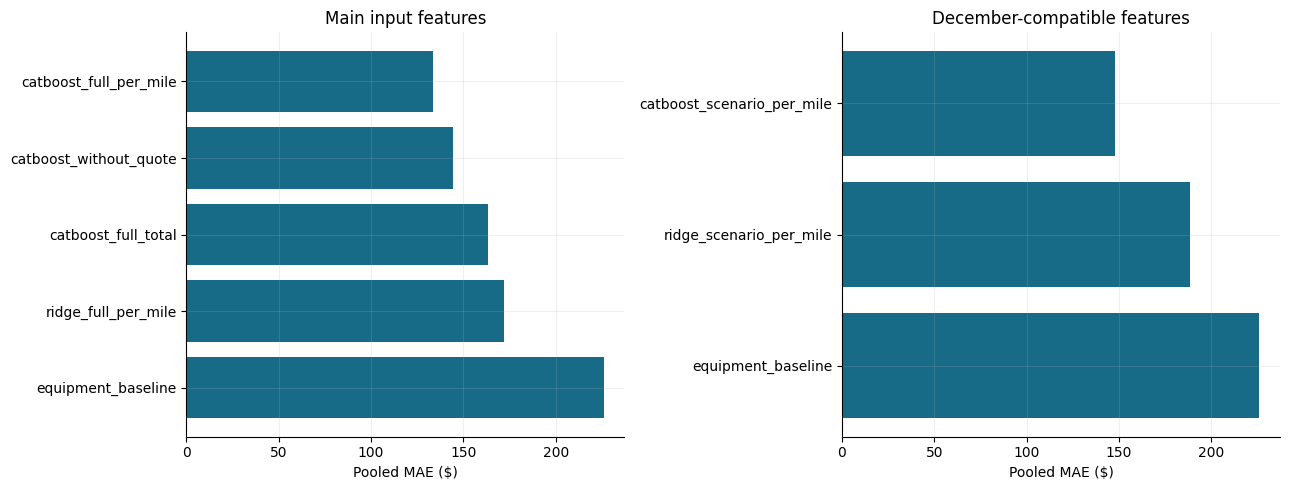

experiment,catboost_full_per_mile,catboost_full_total,catboost_scenario_per_mile,catboost_without_quote,equipment_baseline,ridge_full_per_mile,ridge_scenario_per_mile
month,,,,,,,
2025-07,149.03,207.63,211.61,203.84,209.59,233.16,252.74
2025-08,141.94,156.08,115.32,114.64,241.11,114.90,115.12
2025-09,107.87,124.47,114.22,112.83,227.32,164.93,195.77


Diagnostic: main models evaluated with both market and quote signals absent:


,experiment,evaluation_rows,pooled_mae,pooled_rmse,fold_mae_std,clipped_predictions
0,catboost_without_quote,14341,130.60,624.90,28.93,0
1,ridge_full_per_mile,14341,158.48,635.29,44.68,0
2,catboost_full_total,14341,189.11,646.45,47.08,0
3,catboost_full_per_mile,14341,405.18,781.75,200.73,0


In [9]:
def summarize_results(frame):
    summaries = []
    for name, rows in frame.groupby('experiment', sort=False):
        n = int(rows.rows.sum())
        summaries.append({'experiment': name, 'evaluation_rows': n,
                          'pooled_mae': rows.absolute_error_sum.sum() / n,
                          'pooled_rmse': np.sqrt(rows.squared_error_sum.sum() / n),
                          'fold_mae_std': rows.mae.std(ddof=1),
                          'clipped_predictions': int(rows.clipped_predictions.sum())})
    return pd.DataFrame(summaries).sort_values(['pooled_mae', 'pooled_rmse']).reset_index(drop=True)

summary = summarize_results(results)
summary['group'] = summary.experiment.map({e.name: e.group for e in experiments})
main_ranking = summary.loc[summary.group.isin(['main', 'both'])].reset_index(drop=True)
scenario_ranking = summary.loc[summary.group.isin(['scenario', 'both'])].reset_index(drop=True)
BEST_MAIN = main_ranking.loc[0, 'experiment']
BEST_SCENARIO = scenario_ranking.loc[0, 'experiment']
print('Main-input model comparison:')
display(main_ranking.round(2))
print('December-compatible model comparison:')
display(scenario_ranking.round(2))
print('Provisional main selection:', BEST_MAIN)
print('Provisional December selection:', BEST_SCENARIO)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ranking, title in [(axes[0], main_ranking, 'Main input features'),
                            (axes[1], scenario_ranking, 'December-compatible features')]:
    ax.barh(ranking.experiment, ranking.pooled_mae, color='#176B87')
    ax.invert_yaxis()
    ax.set(title=title, xlabel='Pooled MAE ($)')
plt.tight_layout()
plt.show()

display(results.pivot(index='month', columns='experiment', values='mae').round(2))
print('Diagnostic: main models evaluated with both market and quote signals absent:')
display(summarize_results(masked_results).round(2))


## 8. Inspect errors for the selected main approach

These are out-of-fold errors from the model-selection months. Segment counts matter: errors from a very small subgroup are uncertain. Large errors are investigated rather than automatically removed. October targets are still untouched.


,rows,mae,rmse
equipment,,,
Dry Van,8117,132.51,677.81
Flatbed,2594,135.58,402.30
Reefer,3630,133.33,630.62


,rows,mae,rmse
distance_band,,,
0-250,793,50.05,93.57
250-750,4576,59.30,251.42
750-1500,4897,128.56,554.25
1500+,4075,238.19,964.66


,rows,mae,rmse
weight_missing,,,
False,14187,133.37,627.17
True,154,123.98,281.75


,load_id,date,pickup,delivery,equipment,distance,actual_rate,predicted_rate,absolute_error
52707,TR-037765,2025-08-27,Phoenix,Syracuse,Dry Van,2810.9,24294.98,5398.88,18896.10
83326,TR-040097,2025-09-11,Baltimore,Oklahoma City,Reefer,1760.3,20132.37,3851.08,16281.29
83401,TR-040172,2025-09-11,Montgomery,Fresno,Dry Van,2283.4,20361.89,4357.51,16004.38
17189,TR-031260,2025-07-16,Oklahoma City,Baltimore,Reefer,1747.7,19042.39,4039.13,15003.26
49526,TR-034584,2025-08-06,Atlanta,Fresno,Dry Van,2242.0,18972.15,4300.20,14671.95
19004,TR-033075,2025-07-27,Mobile,Phoenix,Reefer,1880.0,17333.65,3954.01,13379.64
50411,TR-035469,2025-08-12,Lexington,Fresno,Dry Van,2305.9,17742.34,4463.45,13278.89
18282,TR-032353,2025-07-23,Phoenix,Nashville,Dry Van,1998.0,16951.43,4179.51,12771.92
83552,TR-040323,2025-09-12,Montgomery,El Paso,Dry Van,1639.9,14949.25,3268.28,11680.97
14754,TR-028825,2025-07-01,Washington,Lubbock,Dry Van,1627.6,14317.13,3437.46,10879.67


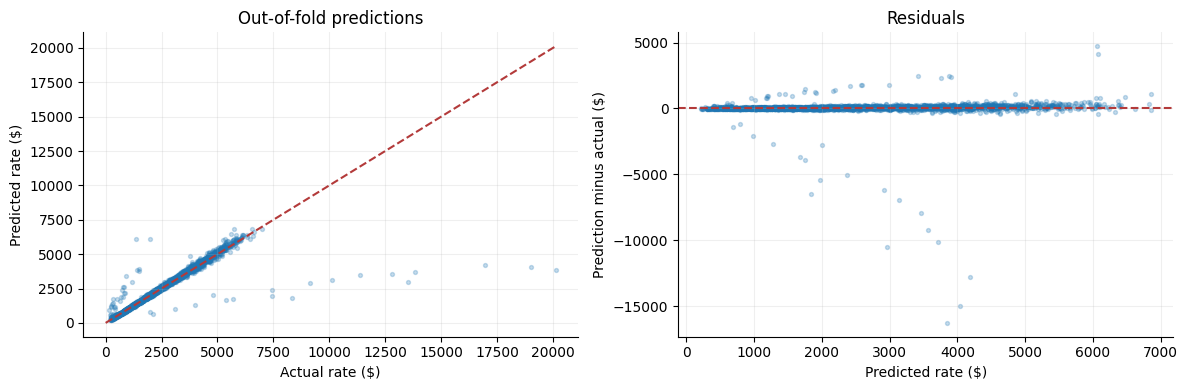

In [10]:
selected_oof = oof.loc[oof.experiment.eq(BEST_MAIN)].copy()
selected_oof['distance_band'] = pd.cut(selected_oof.distance, [0, 250, 750, 1500, np.inf],
                                        labels=['0-250', '250-750', '750-1500', '1500+'])
selected_oof['weight_missing'] = selected_oof.weight.isna()

def segment_errors(frame, column):
    table = frame.groupby(column, observed=True, dropna=False).agg(
        rows=('absolute_error', 'size'), mae=('absolute_error', 'mean'),
        mean_squared_error=('squared_error', 'mean'))
    table['rmse'] = np.sqrt(table.pop('mean_squared_error'))
    return table.round(2)

display(segment_errors(selected_oof, 'equipment'))
display(segment_errors(selected_oof, 'distance_band'))
display(segment_errors(selected_oof, 'weight_missing'))
display(selected_oof.nlargest(10, 'absolute_error')[
    ['load_id', 'date', 'pickup', 'delivery', 'equipment', 'distance',
     'actual_rate', 'predicted_rate', 'absolute_error']].round(2))

sample = selected_oof.sample(min(len(selected_oof), 3000), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sample.actual_rate, sample.predicted_rate, s=8, alpha=0.25)
upper = max(sample.actual_rate.max(), sample.predicted_rate.max())
axes[0].plot([0, upper], [0, upper], '--', color='#B33A3A')
axes[0].set(xlabel='Actual rate ($)', ylabel='Predicted rate ($)', title='Out-of-fold predictions')
axes[1].scatter(sample.predicted_rate, sample.predicted_rate - sample.actual_rate, s=8, alpha=0.25)
axes[1].axhline(0, linestyle='--', color='#B33A3A')
axes[1].set(xlabel='Predicted rate ($)', ylabel='Prediction minus actual ($)', title='Residuals')
plt.tight_layout()
plt.show()


## 9. Review December coverage and feature influence

The scenario comparison evaluates missing-feature availability on varied shipments. It cannot prove accuracy on the fixed December route or future December dates. Report the route's sample count and any limitations. A separate scenario model uses only the available December features during fitting; disclose that separately from the main submission model.

CatBoost feature importance below is diagnostic for the last model-selection fold. It is not causal evidence or a substitute for checking when market and quote signals are generated.


Model-selection evaluation rows on Lexington -> Fort Wayne, Dry Van: 3


,rows,mae,rmse
month,,,
2025-07,1,39.91,39.91
2025-08,1,26.56,26.56
2025-09,1,5.01,5.01


log_distance            21.02
equipment               17.89
distance                16.77
quote_signal            11.58
weight                   7.13
market_index             5.25
delivery                 4.25
pickup                   3.82
days_since_reference     2.12
year_cos                 2.00
day_of_year              1.74
route                    1.65
Name: importance, dtype: float64

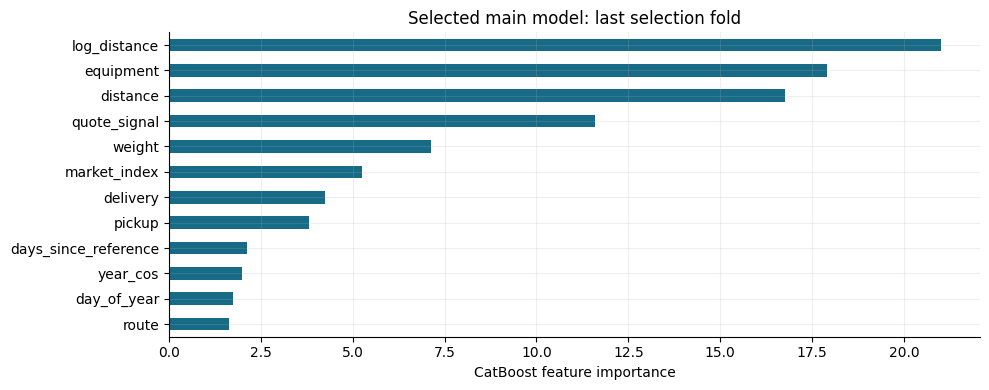

In [11]:
scenario_oof = oof.loc[oof.experiment.eq(BEST_SCENARIO)]
fixed_route = (scenario_oof.pickup.eq('Lexington') & scenario_oof.delivery.eq('Fort Wayne')
               & scenario_oof.equipment.eq('Dry Van'))
route_errors = scenario_oof.loc[fixed_route]
print('Model-selection evaluation rows on Lexington -> Fort Wayne, Dry Van:', len(route_errors))
if len(route_errors):
    display(segment_errors(route_errors, 'month'))
else:
    print('No route-specific evaluation evidence; report this limitation.')

selected_spec = specs[BEST_MAIN]
if selected_spec.algorithm == 'catboost':
    fitted = last_fold_models[BEST_MAIN]['estimator']
    importance = pd.Series(fitted.feature_importances_, index=fitted.feature_names_,
                           name='importance').sort_values(ascending=False)
    display(importance.head(12).round(2))
    importance.head(12).sort_values().plot.barh(color='#176B87')
    plt.xlabel('CatBoost feature importance')
    plt.title('Selected main model: last selection fold')
    plt.tight_layout()
    plt.show()
else:
    print('Use the fold comparisons and quote-signal ablation to explain this selection.')


## 10. Optional one-time October evaluation

Keep `RUN_FINAL_HOLDOUT = False` while experimenting. After freezing the models and settings, enable it once and run the notebook to evaluate the selected approaches on October. Reusing October to alter choices would make it part of model selection rather than an untouched holdout. An existing saved holdout result prevents an accidental repeat.

This notebook does not train final submission models or generate final predictions; that belongs in the next training and prediction scripts.


In [12]:
holdout_report = None
if RUN_FINAL_HOLDOUT:
    existing_report = OUTPUT_DIR / 'final_holdout_metrics.json'
    if existing_report.exists():
        raise RuntimeError('A final holdout report already exists. Review the saved result; do not retune on October.')
    holdout_report = {}
    for role, name in [('main', BEST_MAIN), ('december_scenario', BEST_SCENARIO)]:
        spec = specs[name]
        fitted = fit_experiment(spec, earlier)
        predictions, clipped = predict_experiment(spec, fitted, holdout)
        holdout_report[role] = {'experiment': name, 'clipped_predictions': clipped,
                                **evaluate(holdout[TARGET_COLUMN].to_numpy(), predictions)}
    display(pd.DataFrame(holdout_report).T)
else:
    print('October evaluation skipped. Selection used only earlier chronological folds.')


October evaluation skipped. Selection used only earlier chronological folds.


## 11. Save reproducible experiment results

The saved configuration records the feature choices, fixed hyperparameters, fold boundaries, positive-rate floor and package versions. The JSON names the selected candidates for implementation in `src/train.py`; it contains no trained model. The out-of-fold prediction CSV supports independent verification of the reported metrics. No source CSV is overwritten.


In [13]:
selected_configuration = {
    'selection_metric': 'pooled_mae', 'tie_breaker': 'pooled_rmse',
    'main': asdict(specs[BEST_MAIN]), 'december_scenario': asdict(specs[BEST_SCENARIO]),
    'hyperparameters': {'seed': SEED, 'catboost_iterations': CATBOOST_ITERATIONS,
                        'catboost_depth': CATBOOST_DEPTH, 'catboost_learning_rate': CATBOOST_LEARNING_RATE,
                        'catboost_threads': CATBOOST_THREADS, 'catboost_l2_leaf_reg': 3.0,
                        'ridge_alpha': RIDGE_ALPHA, 'minimum_total_rate': MIN_RATE},
    'holdout_start': str(HOLDOUT_START.date()),
    'selection_folds': [f['month'] for f in folds], 'versions': VERSIONS,
    'signal_availability': 'Confirm quote_signal and market_index availability before final model choice.',
    'final_holdout_evaluated': RUN_FINAL_HOLDOUT,
}
if SAVE_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    results.to_csv(OUTPUT_DIR / 'fold_metrics.csv', index=False)
    summary.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
    masked_results.to_csv(OUTPUT_DIR / 'missing_signal_diagnostics.csv', index=False)
    oof.to_csv(OUTPUT_DIR / 'out_of_fold_predictions.csv', index=False)
    (OUTPUT_DIR / 'selected_configuration.json').write_text(
        json.dumps(selected_configuration, indent=2) + '\n')
    if holdout_report is not None:
        (OUTPUT_DIR / 'final_holdout_metrics.json').write_text(json.dumps(holdout_report, indent=2) + '\n')
    print('Saved experiment outputs to:', OUTPUT_DIR)
else:
    print('SAVE_RESULTS=False: no output files written.')


Saved experiment outputs to: /Users/wijamuni/Projects/Spotter/outputs/model_experiments


## Decisions to carry into training

Record the selected approaches and their measured errors from the executed tables. Explain the observed quote-signal ablation, the December feature limitation, any small route sample, and the cleaning rules. Model performance here measures labeled development splits; it does not reveal the provider's hidden validation metrics.

Next, implement `src/train.py` to reuse the selected configuration, record the frozen holdout evaluation, and refit final models on all eligible labeled data. Save each model together with its target-space choice, feature configuration and preprocessing. Use `src/predict.py` and `src/predict_december.py` to generate predictions with the exact same transformations.
